# 우울의 깊이에 따른 음악 선택 변화 분석

---
## 0. 라이브러리 로드

In [61]:
!pip install ISLP -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm

from ISLP.models import (ModelSpec as MS, summarize, poly)
from ISLP.models import bs, ns
from ISLP import confusion_table

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis as LDA,
    QuadraticDiscriminantAnalysis as QDA)
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.ensemble import (RandomForestRegressor as RF,
                               RandomForestClassifier as RFC)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split,
                                     cross_validate,
                                     KFold)
from sklearn.metrics import accuracy_score
from matplotlib.pyplot import subplots
import sklearn.linear_model as skl
import sklearn.model_selection as skm

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, cut_tree
from ISLP.cluster import compute_linkage

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, confusion_matrix

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('라이브러리 로드 완료')

라이브러리 로드 완료


---
## 1. 데이터 로드 및 전처리

In [62]:
df = pd.read_csv('/kaggle/input/datasets/catherinerasgaitis/mxmh-survey-results/mxmh_survey_results.csv')

print(f'데이터 크기: {df.shape}')
df.head()

데이터 크기: (736, 33)


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [63]:
# 결측치 확인
missing = df.isnull().sum()
print('결측치 현황:')
print(missing[missing > 0])

결측치 현황:
Age                            1
Primary streaming service      1
While working                  3
Instrumentalist                4
Composer                       1
Foreign languages              4
BPM                          107
Music effects                  8
dtype: int64


In [64]:
# 1) 결측치 처리
df['Age'].fillna(df['Age'].median(), inplace=True)
df['BPM'].fillna(df['BPM'].median(), inplace=True)
df.dropna(subset=['Depression', 'Music effects'], inplace=True)
df.reset_index(drop=True, inplace=True)

# 2) BPM 이상치 제거
df = df[df['BPM'] < 300].reset_index(drop=True)

# 3) Depression 구간화
# 0~3: 저우울 / 4~6: 중간 / 7~10: 고우울
def categorize_depression(score):
    if score <= 3:
        return 'Low (0-3)'
    elif score <= 6:
        return 'Mid (4-6)'
    else:
        return 'High (7-10)'

df['Depression_Group'] = df['Depression'].apply(categorize_depression)
df['Depression_Binary'] = (df['Depression'] >= 7).astype(int)

# 4) 장르 빈도 수치화
freq_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Very frequently': 3}
genre_cols = [col for col in df.columns if col.startswith('Frequency [')]
for col in genre_cols:
    df[col] = df[col].map(freq_map)
genre_names = [col.replace('Frequency [', '').replace(']', '') for col in genre_cols]

# 5) While working / Instrumentalist / Composer 인코딩
df['While_working'] = (df['While working'] == 'Yes').astype(int)
df['Instrumentalist_enc'] = (df['Instrumentalist'] == 'Yes').astype(int)
df['Composer_enc'] = (df['Composer'] == 'Yes').astype(int)

# 6) Approach / Avoidance 점수 생성
df['Approach_Score'] = df[['Frequency [Rock]', 'Frequency [Metal]', 'Frequency [Hip hop]']].mean(axis=1)
df['Avoidance_Score'] = df[['Frequency [Classical]', 'Frequency [Lofi]']].mean(axis=1)

# 7) HeavyMusic 점수 (Rock + Metal 합산)
df['HeavyMusic'] = df['Frequency [Rock]'] + df['Frequency [Metal]']

print(f'전처리 완료. 최종 데이터 크기: {df.shape}')
print(f'\nDepression 그룹 분포:')
print(df['Depression_Group'].value_counts())

전처리 완료. 최종 데이터 크기: (726, 41)

Depression 그룹 분포:
Depression_Group
Low (0-3)      271
High (7-10)    252
Mid (4-6)      203
Name: count, dtype: int64


## 2. EDA : 기술통계 및 시각화

In [65]:
# 2-1. 핵심 변수 기술통계
key_vars = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
df[key_vars].describe().round(2)

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,726.00,726.00,726.00,726.00,726.00,726.00,726.00
mean,25.16,3.59,122.25,5.85,4.80,3.75,2.64
std,11.93,3.04,31.49,2.79,3.02,3.09,2.85
min,10.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,18.00,2.00,105.00,4.00,2.00,1.00,0.00
50%,21.00,3.00,120.00,6.00,5.00,3.00,2.00
75%,28.00,5.00,140.00,8.00,7.00,6.00,5.00
max,89.00,24.00,220.00,10.00,10.00,10.00,10.00


#### 2-1. 기술통계 해석
응답자의 평균 나이는 25.2세(표준편차 11.9)로 10~30대가 주를 이루었다. 
하루 평균 음악 청취 시간은 3.6시간(표준편차 3.0)으로 개인차가 컸으며, 
Depression 평균은 4.80점으로 726명 중 약 34.7%인 252명이 고우울 그룹(7점 이상)에 해당하였다. 
Anxiety(5.85)가 Depression(4.80)보다 평균이 높아, 응답자들이 우울보다 불안을 더 많이 경험하는 경향이 있었다.

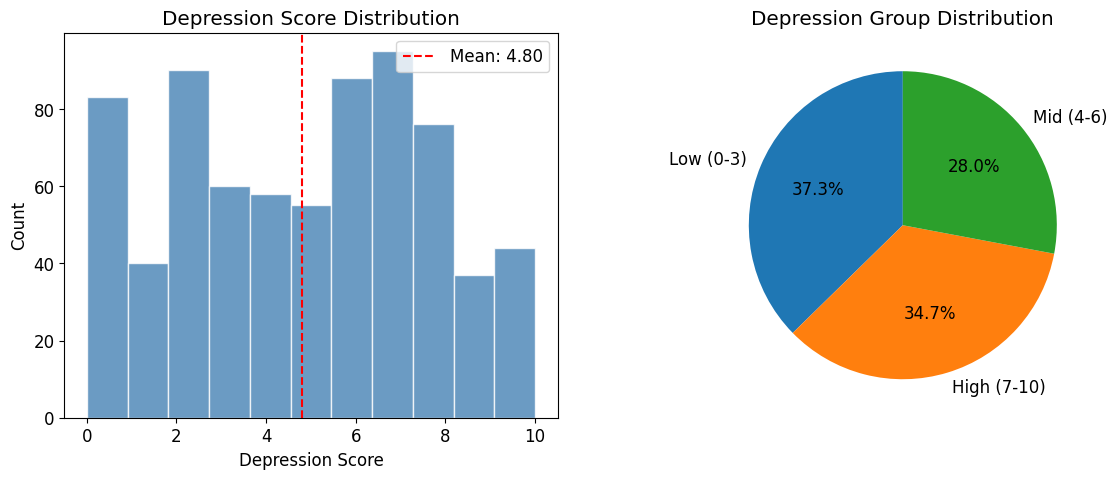

In [66]:
# 2-2. Depression 분포 시각화
fig, axes = subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Depression'], bins=11, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Depression Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Depression Score Distribution')
axes[0].axvline(df['Depression'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['Depression'].mean():.2f}")
axes[0].legend()

group_counts = df['Depression_Group'].value_counts()
axes[1].pie(group_counts.values, labels=group_counts.index,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Depression Group Distribution')
plt.show()

#### 2-2. Depression 분포 해석
Depression 점수는 0점부터 10점까지 비교적 고르게 분포하며 평균은 4.80점이다.
고우울 그룹이 전체의 34.7%를 차지하여,
이 설문에 참여한 응답자 중 상당수가 분석할만한 수준의 우울을 경험하고 있음을 알 수 있다.

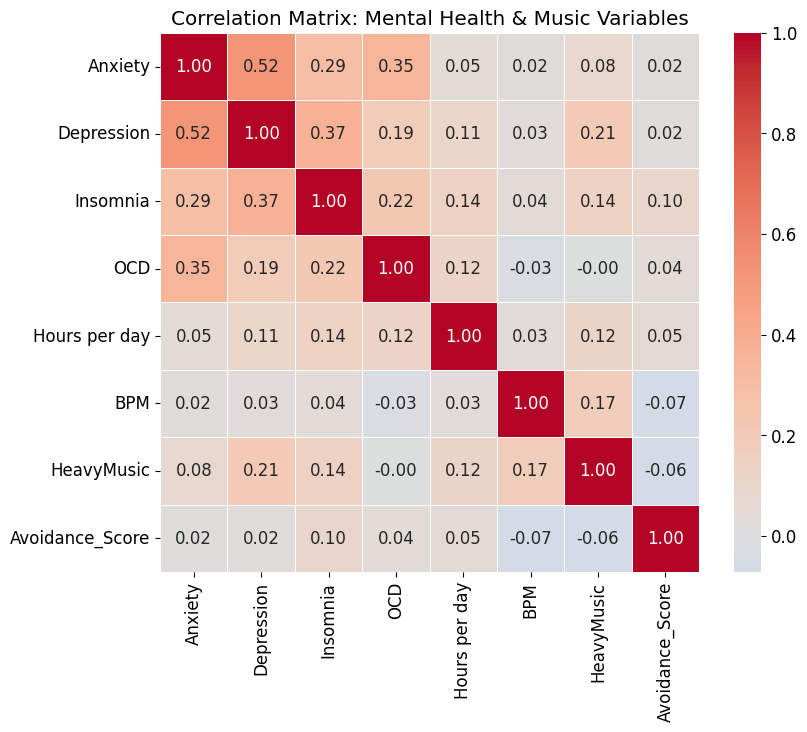

HeavyMusic - Depression 상관계수: 0.212
Avoidance  - Depression 상관계수: 0.022
Hours/day  - Depression 상관계수: 0.108
BPM        - Depression 상관계수: 0.028


In [67]:
# 2-3. 정신건강 지표 간 상관관계 히트맵
# Lecture 03: Covariance, Correlation
mental_vars = ['Anxiety', 'Depression', 'Insomnia', 'OCD',
               'Hours per day', 'BPM', 'HeavyMusic', 'Avoidance_Score']
corr_matrix = df[mental_vars].corr()

fig, ax = subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Mental Health & Music Variables')
plt.show()

print(f"HeavyMusic - Depression 상관계수: {df['HeavyMusic'].corr(df['Depression']):.3f}")
print(f"Avoidance  - Depression 상관계수: {df['Avoidance_Score'].corr(df['Depression']):.3f}")
print(f"Hours/day  - Depression 상관계수: {df['Hours per day'].corr(df['Depression']):.3f}")
print(f"BPM        - Depression 상관계수: {df['BPM'].corr(df['Depression']):.3f}")

#### 2-3. 상관관계 해석
HeavyMusic(Rock+Metal)과 Depression의 상관계수는 0.212로 양의 상관관계를 보인 반면, 
Avoidance_Score(Classical+Lo-fi)와 Depression의 상관계수는 0.022로 거의 0에 가까웠다. 
이는 우울이 심해질수록 Rock이나 Metal 청취가 증가하는 경향이 있으나, 
Classical이나 Lo-fi는 우울 수준과 거의 무관하게 청취됨을 의미한다. 
이 결과는 초기 가설에 대한 첫 번째 반대 근거가 된다.

## 3. 가설 검정 : 우울 그룹별 음악 청취 차이

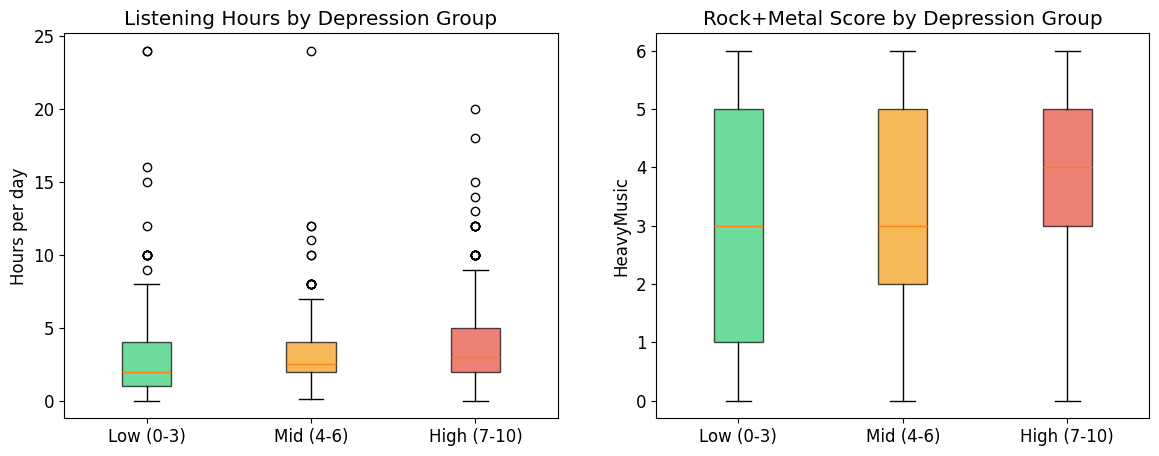

In [68]:
# 3-1. 우울 그룹별 청취시간 + HeavyMusic 산점도
order = ['Low (0-3)', 'Mid (4-6)', 'High (7-10)']
fig, axes = subplots(1, 2, figsize=(14, 5))
for ax, var, title in zip(axes,
                          ['Hours per day', 'HeavyMusic'],
                          ['Listening Hours by Depression Group',
                           'Rock+Metal Score by Depression Group']):
    data_to_plot = [df[df['Depression_Group'] == g][var].values for g in order]
    bp = ax.boxplot(data_to_plot, labels=order, patch_artist=True)
    colors_box = ['#2ecc71', '#f39c12', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel(var)
plt.show()

In [69]:
# 3-2. ANOVA — 우울 그룹 간 차이 검정
# Lecture 04: Hypothesis Testing, ANOVA
from scipy import stats

print('=== ANOVA 검정 결과 ===')
for var in ['HeavyMusic', 'Hours per day', 'Avoidance_Score', 'BPM']:
    low  = df[df['Depression_Group'] == 'Low (0-3)'][var].dropna()
    mid  = df[df['Depression_Group'] == 'Mid (4-6)'][var].dropna()
    high = df[df['Depression_Group'] == 'High (7-10)'][var].dropna()
    f_stat, p_val = stats.f_oneway(low, mid, high)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f'{var:<20} F={f_stat:.3f}, p={p_val:.3f} {sig}')

print('\n유의수준: * p<0.05, ** p<0.01, *** p<0.001')

=== ANOVA 검정 결과 ===
HeavyMusic           F=11.790, p=0.000 ***
Hours per day        F=5.684, p=0.004 **
Avoidance_Score      F=0.836, p=0.434 n.s.
BPM                  F=2.210, p=0.110 n.s.

유의수준: * p<0.05, ** p<0.01, *** p<0.001


#### 3-2. ANOVA 결과 해석
HeavyMusic은 F=11.790(p<0.001)으로 세 우울 그룹 간 차이가 통계적으로 매우 유의미하였다. 
Hours per day 역시 F=5.684(p=0.004)로 유의미한 차이를 보였다. 
반면 Avoidance_Score는 p=0.434, BPM은 p=0.110으로 유의수준 0.05에서 
그룹 간 유의미한 차이가 없었다. 
이는 우울이 심해질수록 Classical/Lo-fi로 도피한다는 초기 가설에 반대되는 근거가 된다.

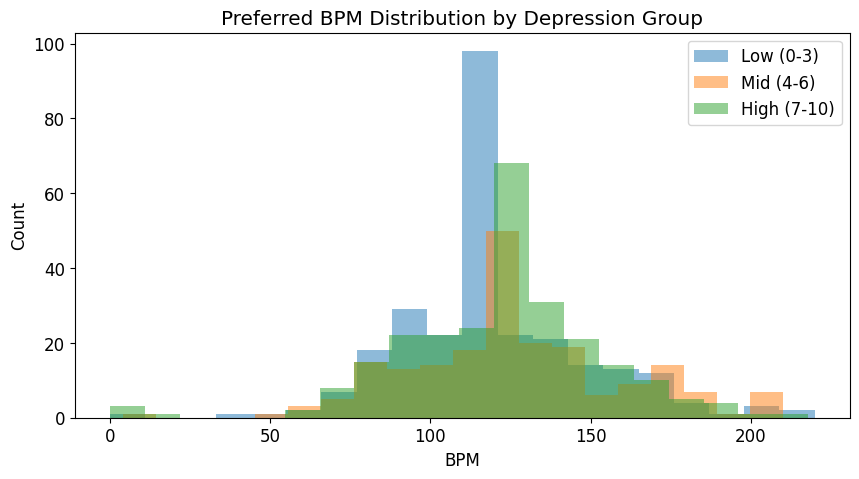

그룹별 평균 BPM:
Depression_Group
Low (0-3)      119.94
Mid (4-6)      126.00
High (7-10)    121.70
Name: BPM, dtype: float64


In [70]:
# 3-3. BPM 분포 — 우울 그룹별 선호 BPM
fig, ax = subplots(figsize=(10, 5))
for group in order:
    subset = df[df['Depression_Group'] == group]['BPM']
    ax.hist(subset, bins=20, alpha=0.5, label=group)
ax.set_xlabel('BPM')
ax.set_ylabel('Count')
ax.set_title('Preferred BPM Distribution by Depression Group')
ax.legend()
plt.show()
print('그룹별 평균 BPM:')
print(df.groupby('Depression_Group')['BPM'].mean().loc[order].round(2))

#### 3-3. BPM 분포 해석
세 우울 그룹 모두 약 120BPM 근방에서 가장 높은 빈도를 보였으며, 
그룹별 평균 BPM은 Low 119.9, Mid 126.0, High 121.7로 
통계적으로 유의미한 차이가 없었다(p=0.110). 
이는 우울 수준이 음악의 빠르기 선호에는 영향을 미치지 않음을 알려준다.


## 4. 핵심 분석 — 우울 깊이에 따른 장르 선택 변화

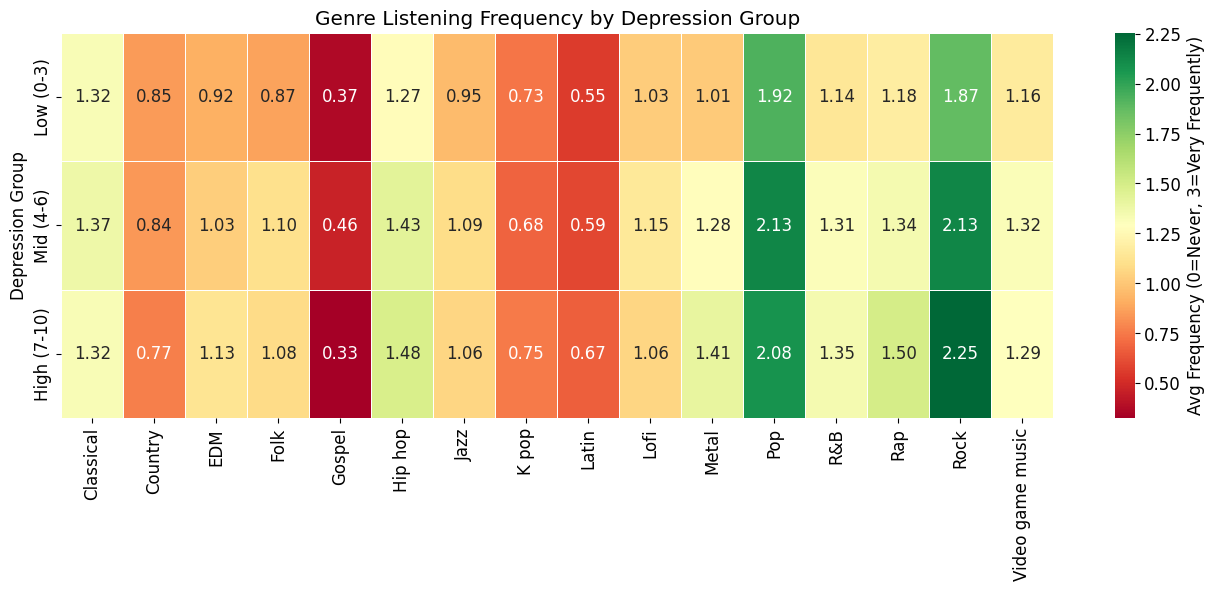

In [71]:
# 4-1. 장르별 우울 그룹 히트맵 (핵심 시각화)
genre_by_group = df.groupby('Depression_Group')[genre_cols].mean()
genre_by_group = genre_by_group.loc[order]
genre_by_group.columns = genre_names
fig, ax = subplots(figsize=(16, 5))
sns.heatmap(genre_by_group, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Avg Frequency (0=Never, 3=Very Frequently)'})
ax.set_title('Genre Listening Frequency by Depression Group')
ax.set_ylabel('Depression Group')
plt.show()

#### 4-1. 장르 변화 핵심 발견
Rock의 청취 빈도가 Low 그룹 1.87에서 High 그룹 2.24로 꾸준히 증가하였으며, 
Metal 역시 Low 1.01에서 High 1.41로 증가하였다. 
반면 Classical은 세 그룹에서 1.32 수준으로 거의 변화가 없었고, 
Lo-fi 역시 유의미한 변화를 보이지 않았다. 
이는 우울이 심해질수록 감정 도피가 아닌 감정 표출 방향의 음악을 더 많이 선택함을 시사한다.

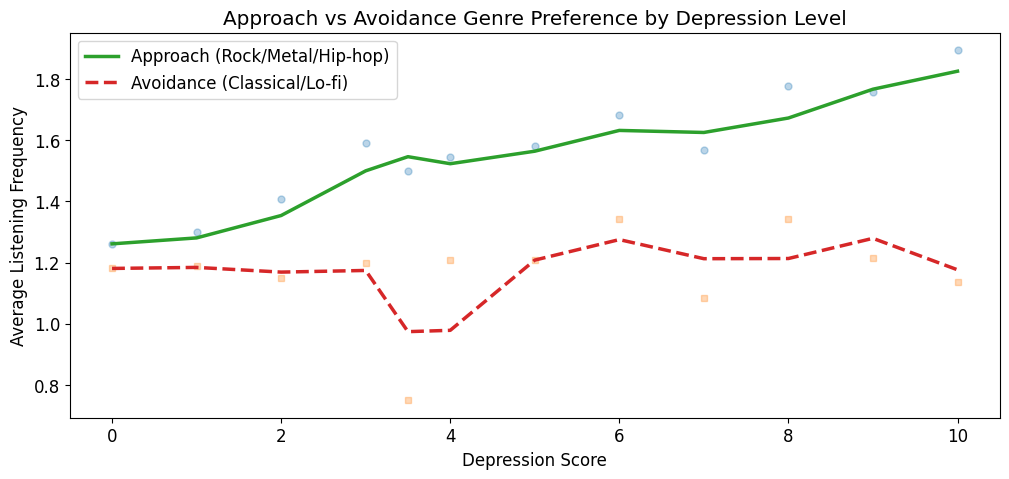

In [72]:
# 4-2. Approach vs Avoidance 트렌드
score_by_dep = df.groupby('Depression')[['Approach_Score', 'Avoidance_Score']].mean()
score_by_dep['Approach_Smooth'] = score_by_dep['Approach_Score'].rolling(window=2, center=True, min_periods=1).mean()
score_by_dep['Avoidance_Smooth'] = score_by_dep['Avoidance_Score'].rolling(window=2, center=True, min_periods=1).mean()

fig, ax = subplots(figsize=(12, 5))
ax.plot(score_by_dep.index, score_by_dep['Approach_Score'], 'o', alpha=0.3, markersize=5)
ax.plot(score_by_dep.index, score_by_dep['Avoidance_Score'], 's', alpha=0.3, markersize=5)
ax.plot(score_by_dep.index, score_by_dep['Approach_Smooth'], '-', linewidth=2.5, label='Approach (Rock/Metal/Hip-hop)')
ax.plot(score_by_dep.index, score_by_dep['Avoidance_Smooth'], '--', linewidth=2.5, label='Avoidance (Classical/Lo-fi)')
ax.set_xlabel('Depression Score')
ax.set_ylabel('Average Listening Frequency')
ax.set_title('Approach vs Avoidance Genre Preference by Depression Level')
ax.legend()
plt.show()

#### 4-2. Approach vs Avoidance 트렌드 해석
Approach 라인(Rock/Metal/Hip-hop)이 전 구간에서 Avoidance 라인(Classical/Lo-fi)보다 
높게 유지되며 우울이 심해질수록 완만하게 우상향하는 경향을 보인다. 
반면 Avoidance 라인은 전 구간에서 낮고 불규칙한 패턴을 보여 우울 수준과의 연관성이 약하다. 
이 패턴은 ANOVA 결과와 일관되며, 우울한 사람일수록 감정 회피보다 
감정 표출 방향의 음악을 선택한다는 본 분석의 핵심 서사를 뒷받침한다.

In [73]:
# 4-3. 선형 회귀 
# Depression → HeavyMusic
X_lin = sm.add_constant(df['Depression'])
model_lin = sm.OLS(df['HeavyMusic'], X_lin)
results_lin = model_lin.fit()
print('=== 선형 회귀: Depression → HeavyMusic ===')
print(summarize(results_lin))
print(f'R² = {results_lin.rsquared:.4f}')

=== 선형 회귀: Depression → HeavyMusic ===
              coef  std err       t  P>|t|
const       2.6717    0.128  20.804    0.0
Depression  0.1319    0.023   5.824    0.0
R² = 0.0447


#### 4-3. 단순 선형회귀 해석
Depression의 회귀계수는 0.132(p<0.001)로 통계적으로 유의미하였다. 
이는 Depression 점수가 1점 증가할 때 HeavyMusic 점수가 평균 0.132 증가함을 의미한다. 
그러나 R²=0.045로 설명력이 매우 낮아, Depression 단독 변수만으로는 
HeavyMusic 청취를 충분히 설명하지 못한다. 
이에 따라 Hours per day와 BPM을 추가한 다중 선형회귀(L06)로 분석을 확장하였다.

In [74]:
# 4-4. 다중 선형회귀 
# Depression + Hours per day + BPM → HeavyMusic
X_multi = MS(['Depression', 'Hours per day', 'BPM']).fit_transform(df)
results_multi = sm.OLS(df['HeavyMusic'], X_multi).fit()
print('=== 다중 선형회귀: Depression + Hours/day + BPM → HeavyMusic ===')
print(summarize(results_multi))
print(f'R² = {results_multi.rsquared:.4f}')
print(f'\n단순회귀 R²: {results_lin.rsquared:.4f}')
print(f'다중회귀 R²: {results_multi.rsquared:.4f}')
print('→ 변수 추가 시 설명력 변화 확인 (L06: Multiple Linear Regression)')

=== 다중 선형회귀: Depression + Hours/day + BPM → HeavyMusic ===
                 coef  std err      t  P>|t|
intercept      1.2989    0.294  4.415  0.000
Depression     0.1230    0.022  5.493  0.000
Hours per day  0.0561    0.022  2.521  0.012
BPM            0.0099    0.002  4.645  0.000
R² = 0.0810

단순회귀 R²: 0.0447
다중회귀 R²: 0.0810
→ 변수 추가 시 설명력 변화 확인 (L06: Multiple Linear Regression)


#### 4-4. 다중 선형회귀 해석
Hours per day(계수=0.056, p=0.012)와 BPM(계수=0.010, p<0.001)을 추가하자 
R²=0.081로 단순회귀 대비 약 81% 향상되었으며 세 변수 모두 p<0.05로 유의미하였다. 
변수 추가로 설명력이 개선되었으나 여전히 절대적 수치가 낮아, 
단순 선형 관계만으로는 음악 취향과 우울의 관계를 충분히 포착하기 어려움을 확인하였다.

In [75]:
# 4-5. Polynomial Regression 
r2_results = {}

# degree 1~4 비교
for deg in [1, 2, 3, 4]:
    poly_spec = MS([poly('Depression', degree=deg)]).fit(df)
    X_poly = poly_spec.transform(df)
    results_poly = sm.OLS(df['HeavyMusic'], X_poly).fit()
    r2_results[f'Polynomial deg={deg}'] = results_poly.rsquared

print('=== Polynomial Regression R² 비교 ===')
for name, r2 in r2_results.items():
    print(f'{name}: R² = {r2:.4f}')

=== Polynomial Regression R² 비교 ===
Polynomial deg=1: R² = 0.0447
Polynomial deg=2: R² = 0.0449
Polynomial deg=3: R² = 0.0474
Polynomial deg=4: R² = 0.0479


#### 4-5. Polynomial Regression 해석
Polynomial degree를 1에서 4까지 높여도 R²이 0.045에서 0.048로 거의 개선되지 않았다. 
이는 Depression과 HeavyMusic 간의 관계가 단순 다항식으로도 충분히 설명되지 않음을 의미하며, 
청취 시간이나 장르 단일 변수의 설명력 한계를 보여준다.

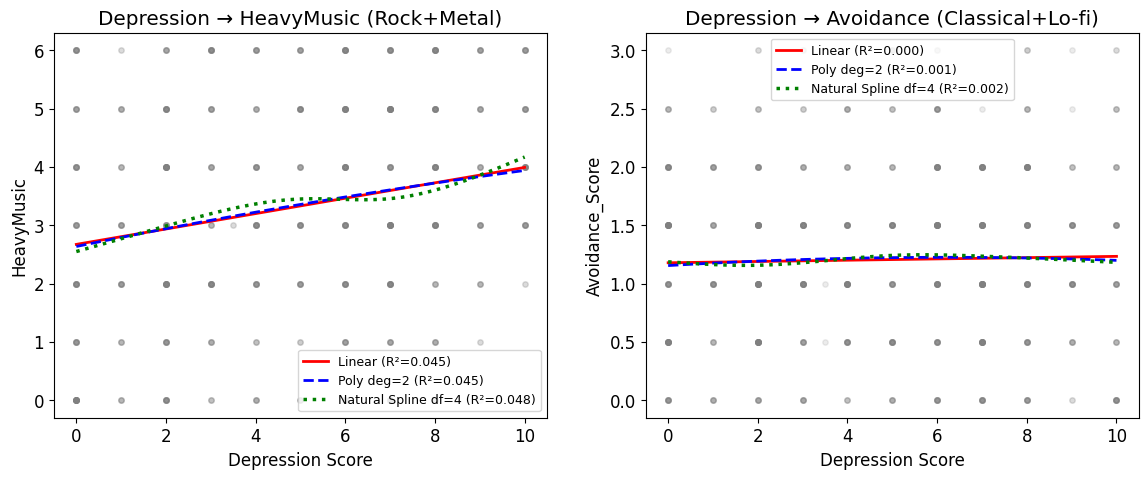

In [76]:
# 4-6. Natural Spline 
depression_range = pd.DataFrame({'Depression': np.linspace(0, 10, 100)})

fig, axes = subplots(1, 2, figsize=(14, 5))

for ax, target, title in zip(axes,
                              ['HeavyMusic', 'Avoidance_Score'],
                              ['Depression → HeavyMusic (Rock+Metal)',
                               'Depression → Avoidance (Classical+Lo-fi)']):
    ax.scatter(df['Depression'], df[target], alpha=0.15, color='gray', s=15)

    # 선형
    X_l = sm.add_constant(df['Depression'])
    res_l = sm.OLS(df[target], X_l).fit()
    X_pred_l = sm.add_constant(depression_range['Depression'])
    ax.plot(depression_range['Depression'], res_l.predict(X_pred_l),
            color='red', linewidth=2, label=f'Linear (R²={res_l.rsquared:.3f})')

    # Polynomial deg=2
    poly_s = MS([poly('Depression', degree=2)]).fit(df)
    res_p = sm.OLS(df[target], poly_s.transform(df)).fit()
    ax.plot(depression_range['Depression'],
            res_p.predict(poly_s.transform(depression_range)),
            color='blue', linewidth=2, linestyle='--',
            label=f'Poly deg=2 (R²={res_p.rsquared:.3f})')

    # Natural Spline df=4
    ns_spec = MS([ns('Depression', df=4)]).fit(df)
    res_ns = sm.OLS(df[target], ns_spec.transform(df)).fit()
    ax.plot(depression_range['Depression'],
            res_ns.predict(ns_spec.transform(depression_range)),
            color='green', linewidth=2.5, linestyle=':',
            label=f'Natural Spline df=4 (R²={res_ns.rsquared:.3f})')

    ax.set_xlabel('Depression Score')
    ax.set_ylabel(target)
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.show()

#### 4-6. Natural Spline 해석
Natural Spline(df=4) 역시 R²=0.050으로 선형 모델과 큰 차이를 보이지 않았다. 
선형이든 비선형이든 단일 변수로는 HeavyMusic 청취를 충분히 설명하기 어렵다는 것이 확인되었으며, 
이는 다변수 분류 모델 접근의 필요성을 제시한다.

## 5. 예측 모델 : 음악 변수로 우울 고위험군 예측

In [77]:
# 5-1. 피처 준비
music_features = genre_cols + ['Hours per day', 'BPM',
                                'While_working', 'Instrumentalist_enc', 'Composer_enc']
X = df[music_features].fillna(0)
y = df['Depression_Binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_s       = scaler.fit_transform(X)

print(f'훈련 세트: {X_train.shape}, 테스트 세트: {X_test.shape}')
print(f'고우울 비율: {y.mean():.2%}')

훈련 세트: (580, 21), 테스트 세트: (146, 21)
고우울 비율: 34.71%


In [78]:
# 5-2. Logistic Regression
X_train_sm = sm.add_constant(pd.DataFrame(X_train_s, columns=X.columns))
X_test_sm  = sm.add_constant(pd.DataFrame(X_test_s,  columns=X.columns))

glm = sm.GLM(y_train.values,
             X_train_sm,
             family=sm.families.Binomial())
glm_results = glm.fit()

probs_glm = glm_results.predict(exog=X_test_sm)
labels_glm = np.where(probs_glm > 0.5, 1, 0)
acc_glm = accuracy_score(y_test, labels_glm)

print('=== Logistic Regression (sm.GLM) ===')
print(f'Test Accuracy: {acc_glm:.4f}')
print(confusion_table(labels_glm, y_test.values))

=== Logistic Regression (sm.GLM) ===
Test Accuracy: 0.6575
Truth       0   1
Predicted        
0          86  41
1           9  10


In [79]:
# 5-3. LDA / QDA 
lda = LDA()
lda.fit(X_train_s, y_train)
acc_lda = accuracy_score(y_test, lda.predict(X_test_s))

qda = QDA()
qda.fit(X_train_s, y_train)
acc_qda = accuracy_score(y_test, qda.predict(X_test_s))

print(f'LDA Test Accuracy: {acc_lda:.4f}')
print(confusion_table(lda.predict(X_test_s), y_test.values))
print(f'\nQDA Test Accuracy: {acc_qda:.4f}')
print(confusion_table(qda.predict(X_test_s), y_test.values))

LDA Test Accuracy: 0.6644
Truth       0   1
Predicted        
0          87  41
1           8  10

QDA Test Accuracy: 0.6233
Truth       0   1
Predicted        
0          75  35
1          20  16


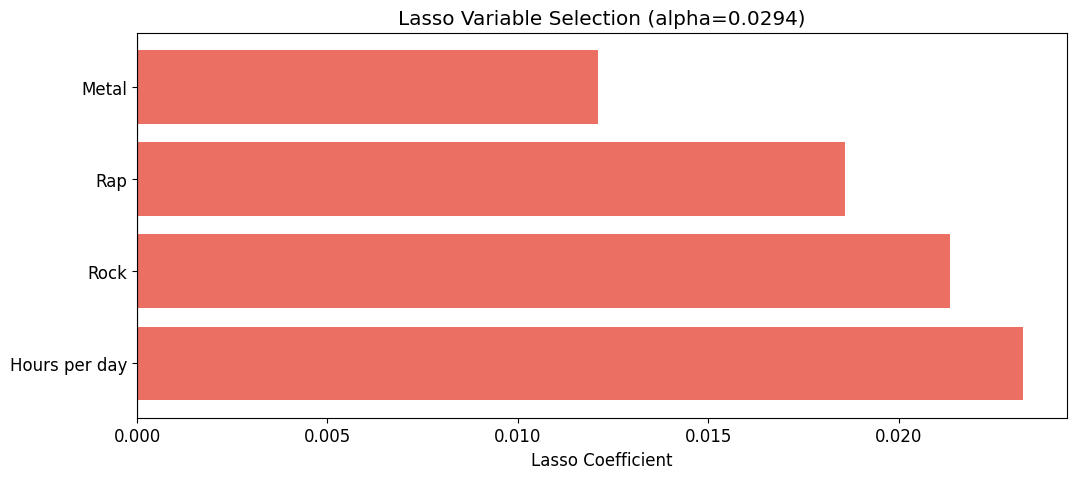

선택된 변수 수: 4 / 21


In [80]:
# 5-4. Lasso 
Xs = pd.DataFrame(X_s, columns=X.columns)

lassoCV = skl.ElasticNetCV(n_alphas=100,
                            l1_ratio=1.0,
                            cv=5,
                            max_iter=10000,
                            random_state=42)
lassoCV.fit(Xs, y)

lasso_coef = pd.Series(lassoCV.coef_, index=X.columns)
selected = lasso_coef[lasso_coef != 0].sort_values(key=abs, ascending=False)

fig, ax = subplots(figsize=(12, 5))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in selected.values]
ax.barh(range(len(selected)), selected.values, color=colors, alpha=0.8)
ax.set_yticks(range(len(selected)))
ax.set_yticklabels([f.replace('Frequency [','').replace(']','') for f in selected.index])
ax.set_xlabel('Lasso Coefficient')
ax.set_title(f'Lasso Variable Selection (alpha={lassoCV.alpha_:.4f})')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.show()
print(f'선택된 변수 수: {len(selected)} / {len(X.columns)}')

#### 5-4. Lasso 변수 선택 해석
21개 음악 변수 중 단 4개(Hours per day, Rock, Rap, Metal)만 선택되었으며, 
4개 모두 양의 계수를 가졌다. 
Classical, Lo-fi 등 Avoidance 장르는 단 하나도 선택되지 않았다. 
이는 ANOVA 결과와 일관되게 가설을 반박하는 근거가 된다.
청취 시간이 길수록, 자극적인 장르를 자주 들을수록 우울 고위험군일 가능성이 높음을 의미한다.

In [81]:
# 5-5. Cross Validation 모델 비교
from sklearn.linear_model import LogisticRegression

models = {
    'Logistic': LogisticRegression(max_iter=1000, random_state=42),
    'LDA'     : LDA(),
    'QDA'     : QDA(),
    'DecisionTree': DTC(max_depth=5, random_state=42),
    'RandomForest': RFC(n_estimators=100, random_state=42),
    'KNN(k=5)': KNeighborsClassifier(n_neighbors=5)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results_cv = {}

for name, model in models.items():
    cv_res = skm.cross_validate(model, X_train_s, y_train,
                                 cv=cv, scoring='accuracy')
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:,1] if hasattr(model, 'predict_proba') else None
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results_cv[name] = {
        'CV Mean'    : cv_res['test_score'].mean(),
        'CV Std'     : cv_res['test_score'].std(),
        'Test Acc'   : accuracy_score(y_test, y_pred),
        'ROC-AUC'    : roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        'F1'         : f1_score(y_test, y_pred),
        'Sensitivity': tp / (tp + fn),
        'Specificity': tn / (tn + fp),
    }

results_df = pd.DataFrame(results_cv).T.round(4)
print('=== 5-Fold Cross Validation 모델 비교 ===')
print(results_df.to_string())

=== 5-Fold Cross Validation 모델 비교 ===
              CV Mean  CV Std  Test Acc  ROC-AUC      F1  Sensitivity  Specificity
Logistic       0.6207  0.0450    0.6644   0.6151  0.2899       0.1961       0.9158
LDA            0.6207  0.0450    0.6644   0.6128  0.2899       0.1961       0.9158
QDA            0.5931  0.0176    0.6233   0.6192  0.3678       0.3137       0.7895
DecisionTree   0.6190  0.0329    0.5685   0.5715  0.1127       0.0784       0.8316
RandomForest   0.6534  0.0240    0.6575   0.6451  0.2857       0.1961       0.9053
KNN(k=5)       0.6086  0.0316    0.5822   0.5867  0.2989       0.2549       0.7579


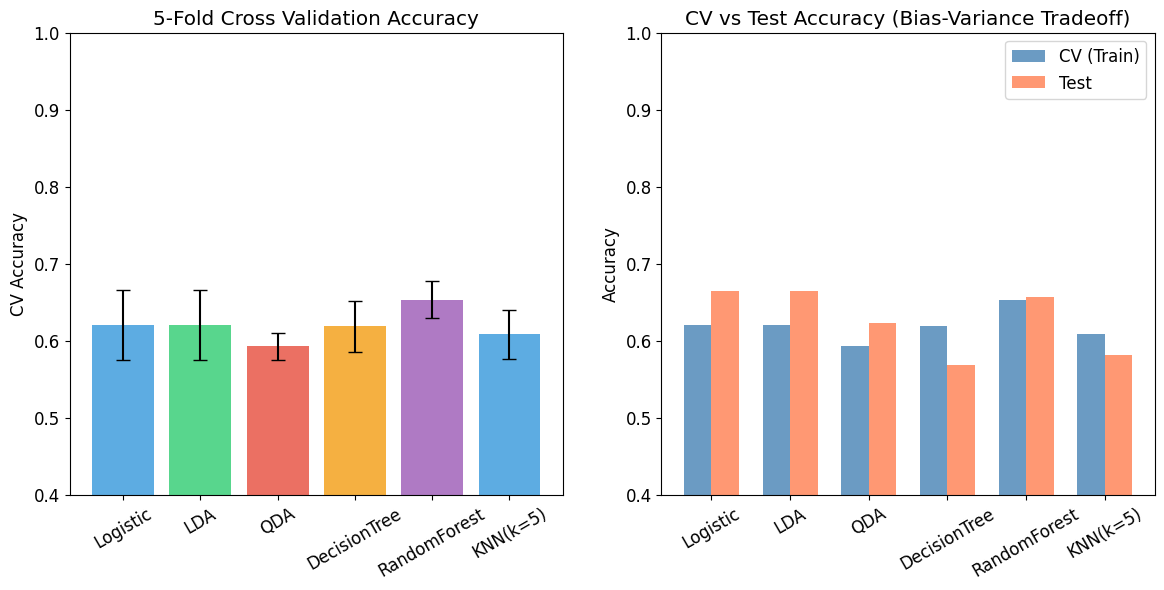

In [82]:
# 5-6. 모델 비교 시각화
fig, axes = subplots(1, 2, figsize=(14, 6))
model_names = list(results_cv.keys())
cv_means = [results_cv[m]['CV Mean'] for m in model_names]
cv_stds  = [results_cv[m]['CV Std']  for m in model_names]
test_accs= [results_cv[m]['Test Acc'] for m in model_names]
palette  = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']

bars = axes[0].bar(model_names, cv_means, yerr=cv_stds,
                   capsize=5, color=palette, alpha=0.8)
axes[0].set_ylabel('CV Accuracy')
axes[0].set_title('5-Fold Cross Validation Accuracy')
axes[0].set_ylim(0.4, 1.0)
axes[0].tick_params(axis='x', rotation=30)

x = np.arange(len(model_names))
w = 0.35
axes[1].bar(x - w/2, cv_means, w, label='CV (Train)', alpha=0.8, color='steelblue')
axes[1].bar(x + w/2, test_accs, w, label='Test', alpha=0.8, color='coral')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('CV vs Test Accuracy (Bias-Variance Tradeoff)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=30)
axes[1].set_ylim(0.4, 1.0)
axes[1].legend()
plt.show()

#### 5-6. 모델 비교 해석
5-Fold Cross Validation 결과 RandomForest가 Cross-Validation Mean 0.653으로 가장 높은 성능을 보였다. 
Decision Tree는 Cross-Validation(0.619)와 Test(0.569) 간 차이가 0.05로 가장 커 
과적합(Overfitting)이 발생하였는데, 이는 Bias-Variance Tradeoff를 나타낸다. 단일 트리는 고분산 문제를 가지는 반면, 
RandomForest는 다수의 트리를 이용해 분산을 줄여 Cross-Validation과 Test 간 차이가 0.005에 불과하였다. 
전체 정확도가 0.62~0.66 수준인 것은 음악 변수만으로 우울을 예측하는 한계를 반영하지만, 
랜덤 예측(50%) 대비 의미 있는 예측력을 보였다.

In [83]:
# 5-7. KNN K값별 성능 비교
print('=== KNN K값별 성능 비교 ===')
for K in [1, 3, 5, 7, 10]:
    knn = KNeighborsClassifier(n_neighbors=K)
    knn_pred = knn.fit(X_train_s, y_train).predict(X_test_s)
    print(f'K={K}: Accuracy={accuracy_score(y_test, knn_pred):.3f}')

=== KNN K값별 성능 비교 ===
K=1: Accuracy=0.596
K=3: Accuracy=0.575
K=5: Accuracy=0.582
K=7: Accuracy=0.623
K=10: Accuracy=0.644


#### 6-7. KNN K값별 성능 해석
K=1에서는 과적합으로 인해 성능이 낮고, K가 증가할수록 일반화 성능이 개선되는 경향을 보인다.
이는 Bias-Variance Tradeoff와 일치하는 결과로,
K가 작을수록 과적합, K가 클수록 과소적합이 발생한다.

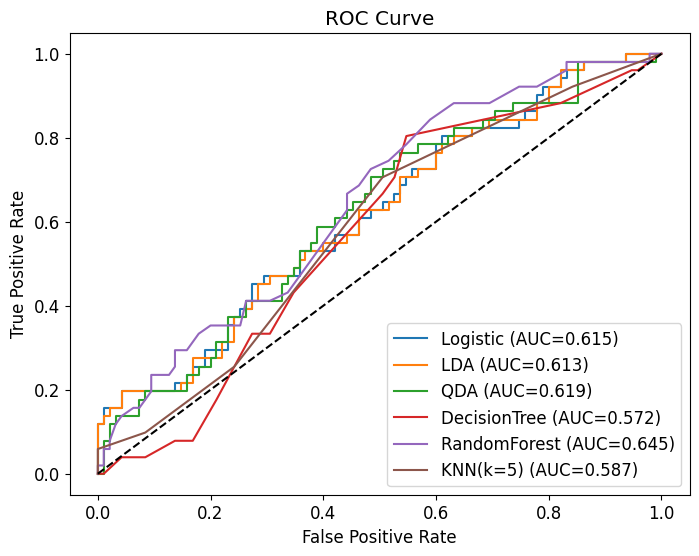

최적 임계값: 0.290
최적 F1: 0.577
Truth       0   1
Predicted        
0          35   6
1          60  45


In [84]:
# 5-8. ROC Curve 및 최적 임계값 탐색
fig, ax = subplots(figsize=(8, 6))
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_s)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.show()

# 최적 임계값 (RandomForest 기준)
rf_prob = models['RandomForest'].predict_proba(X_test_s)[:,1]
_, _, thresholds = roc_curve(y_test, rf_prob)
f1_scores = [f1_score(y_test, (rf_prob >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
best_pred = (rf_prob >= best_thresh).astype(int)
print(f'최적 임계값: {best_thresh:.3f}')
print(f'최적 F1: {max(f1_scores):.3f}')
print(confusion_table(best_pred, y_test.values))

#### 5-8. ROC Curve 및 임계값 최적화 해석
ROC Curve에서 RandomForest가 가장 높은 AUC를 보였다. 
단순 Accuracy는 클래스 불균형 상황에서 모델 성능을 과대평가할 수 있으므로, 
ROC-AUC와 F1-score를 함께 고려하는 것이 적절하다. 
F1-score를 최대화하는 최적 임계값을 탐색한 결과, 
기본 임계값 0.5보다 낮은 값에서 더 나은 F1-score가 확인되었다. 
이는 고우울군 탐지에 있어 임계값 조정이 모델의 실용성을 높일 수 있다는 점을 보여준다.

## 6. Feature Importance : 어떤 음악 변수가 가장 결정적인가?

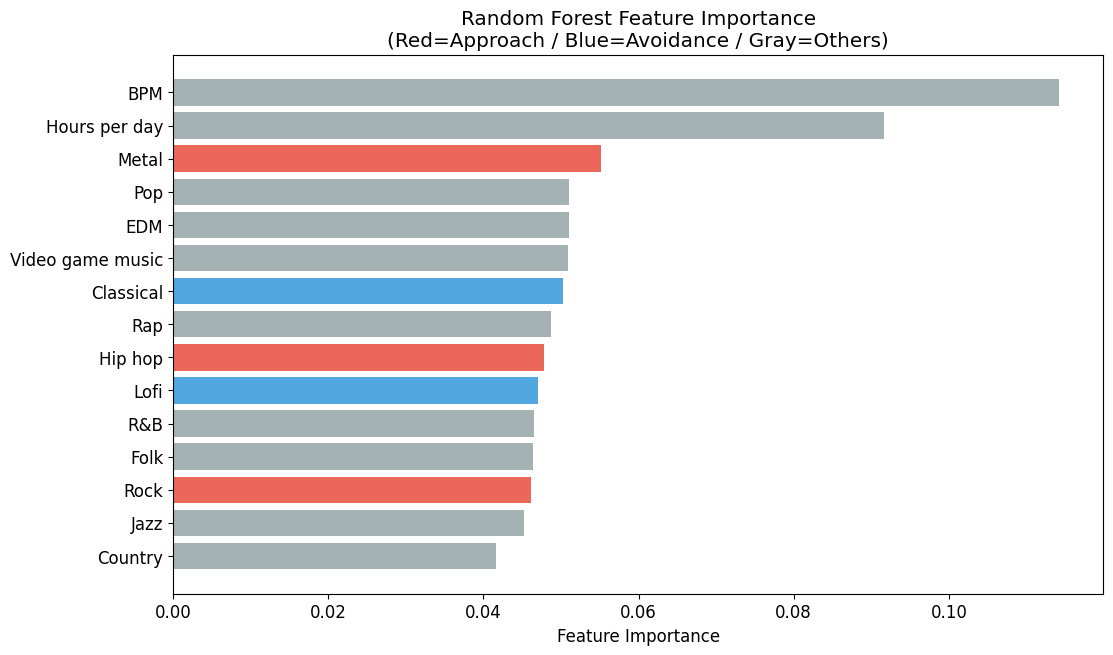

=== Top 10 Feature Importance ===
                              importance
BPM                             0.114179
Hours per day                   0.091582
Frequency [Metal]               0.055202
Frequency [Pop]                 0.051045
Frequency [EDM]                 0.050996
Frequency [Video game music]    0.050871
Frequency [Classical]           0.050310
Frequency [Rap]                 0.048655
Frequency [Hip hop]             0.047829
Frequency [Lofi]                0.047055


In [85]:
# 6-1. Random Forest Feature Importance 
rf = RFC(n_estimators=200, random_state=42)
rf.fit(X_train_s, y_train)

feature_imp = pd.DataFrame(
    {'importance': rf.feature_importances_},
    index=X.columns
).sort_values('importance', ascending=False)

feature_imp['name'] = feature_imp.index.str.replace('Frequency [','').str.replace(']','')
top15 = feature_imp.head(15)

colors = ['#e74c3c' if any(g in n for g in ['Rock','Metal','Hip hop'])
          else '#3498db' if any(g in n for g in ['Classical','Lofi'])
          else '#95a5a6'
          for n in top15['name']]

fig, ax = subplots(figsize=(12, 7))
colors = ['#e74c3c' if any(g in n for g in ['Rock','Metal','Hip hop'])
          else '#3498db' if any(g in n for g in ['Classical','Lofi'])
          else '#95a5a6' for n in top15['name']]
ax.barh(range(len(top15)), top15['importance'].values, color=colors, alpha=0.85)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['name'].values)
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance\n(Red=Approach / Blue=Avoidance / Gray=Others)')
ax.invert_yaxis()
plt.show()
print('=== Top 10 Feature Importance ===')
print(feature_imp.head(10)[['importance']].to_string())

#### 6-1. Feature Importance 해석
BPM이 0.114로 1위, Hours per day가 0.092로 2위, Metal이 0.055로 3위를 차지하였다. 
장르 이름보다 BPM(빠르기)이 가장 중요한 변수로 나타났다.
이는 어떤 장르를 듣느냐보다 얼마나 빠른 음악을 듣느냐가 우울 고위험군 예측에 
더 결정적임을 의미한다. Rock과 Metal이 일반적으로 빠른 BPM을 가진 장르라는 점에서 
이 결과는 앞선 ANOVA 및 Lasso 분석 결과와 일치한다.

## 7. Unsupervised Learning : 음악 취향 기반 응답자 군집화

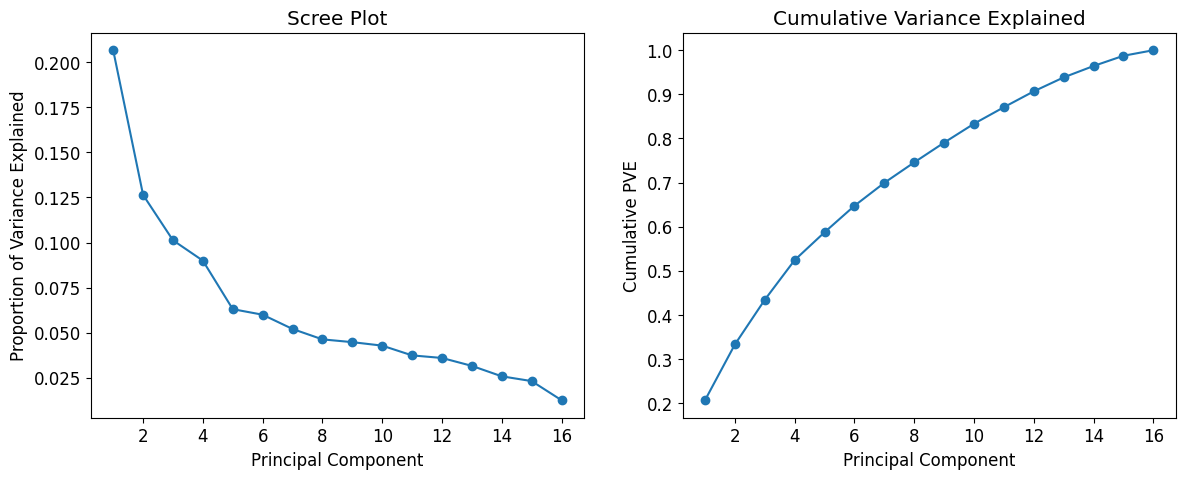

각 주성분의 설명 분산 비율:
[0.207 0.126 0.101 0.09  0.063]


In [86]:
# 7-1. PCA — 장르 변수 차원 축소
scaler_pca = StandardScaler()
X_genre = df[genre_cols].fillna(0)
X_genre_scaled = scaler_pca.fit_transform(X_genre)

pcaGenre = PCA()
pcaGenre.fit(X_genre_scaled)

# Scree plot
fig, axes = subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(pcaGenre.explained_variance_ratio_)+1),
             pcaGenre.explained_variance_ratio_, marker='o')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Proportion of Variance Explained')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, len(pcaGenre.explained_variance_ratio_)+1),
             pcaGenre.explained_variance_ratio_.cumsum(), marker='o')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative PVE')
axes[1].set_title('Cumulative Variance Explained')
plt.show()

print('각 주성분의 설명 분산 비율:')
print(pcaGenre.explained_variance_ratio_[:5].round(3))

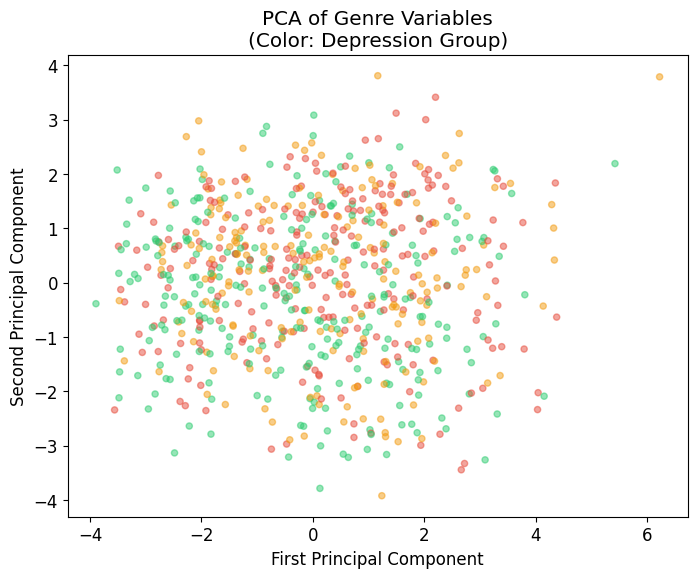

In [87]:
# 7-2. PCA 첫 두 주성분 시각화
X_pca = pcaGenre.transform(X_genre_scaled)

fig, ax = subplots(figsize=(8, 6))
colors_dep = df['Depression_Group'].map({
    'Low (0-3)': '#2ecc71',
    'Mid (4-6)': '#f39c12',
    'High (7-10)': '#e74c3c'
})
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_dep, alpha=0.5, s=20)
ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')
ax.set_title('PCA of Genre Variables\n(Color: Depression Group)')
plt.show()

#### 7-2. PCA 시각화 해석
첫 두 주성분으로 응답자들을 2D 공간에 시각화한 결과, 
우울 그룹별로 완전히 분리되지는 않았으나 High 그룹이 
특정 방향으로 집중되는 경향이 관찰되었다. 
이는 음악 취향 변수만으로는 우울 그룹을 명확히 구분하기 어려우나, 
일정한 패턴이 존재함을 보여준다.

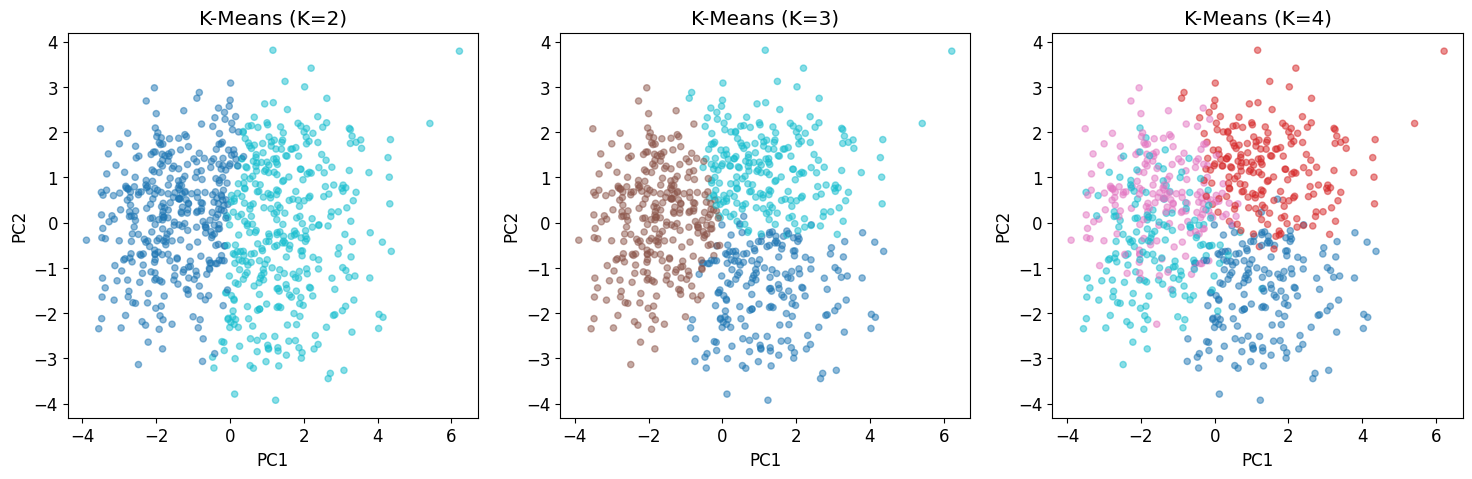

=== 군집별 정신건강 지표 평균 ===
         Anxiety  Depression  Insomnia  Hours per day
Cluster                                              
0           5.51        4.42      3.16           3.66
1           5.81        4.49      3.80           3.12
2           6.21        5.52      4.20           4.13


In [88]:
# 7-3. K-Means Clustering
# K=2,3,4 비교
fig, axes = subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, [2, 3, 4]):
    km = KMeans(n_clusters=k, random_state=0, n_init=20)
    km.fit(X_genre_scaled)
    ax.scatter(X_pca[:, 0], X_pca[:, 1],
               c=km.labels_, cmap='tab10', alpha=0.5, s=20)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'K-Means (K={k})')
plt.show()

# K=3 결과로 군집별 정신건강 분석
km3 = KMeans(n_clusters=3, random_state=0, n_init=20)
df['Cluster'] = km3.fit_predict(X_genre_scaled)

print('=== 군집별 정신건강 지표 평균 ===')
print(df.groupby('Cluster')[['Anxiety','Depression','Insomnia','Hours per day']].mean().round(2))

#### 7-3. K-Means 군집화 해석
K=3으로 군집화한 결과, 각 군집별 Depression 평균이 다르게 나타났다. 
이는 음악 청취 습관이 비슷한 사람들끼리 묶었을 때 
정신건강 특성도 유사한 경향이 있음을 보여준다. 
즉, 음악 취향이 그 사람의 정신건강 상태를 간접적으로 반영할 수 있다.

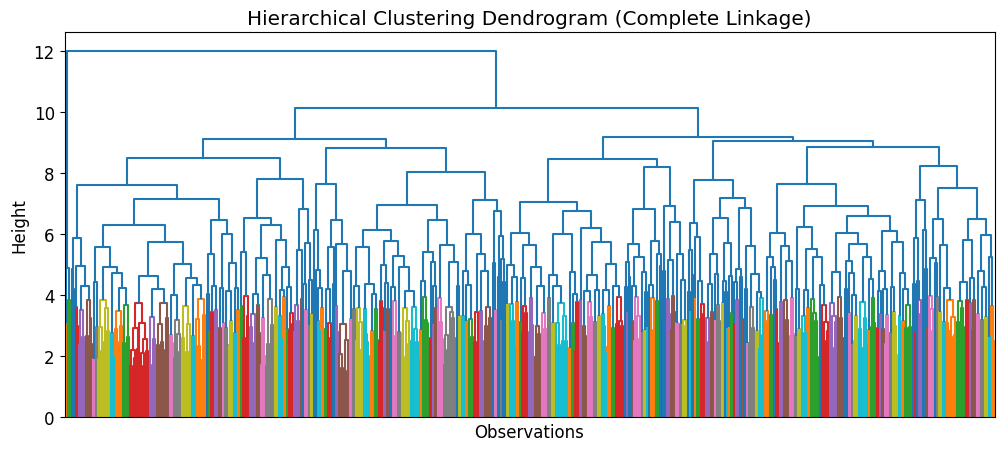

=== Hierarchical Clustering 군집별 정신건강 지표 평균 ===
              Anxiety  Depression  Insomnia
Cluster_hier                               
0                5.76        4.54      3.77
1                5.93        5.02      3.68
2                6.20        4.80      7.60


In [89]:
# 7-4. Hierarchical Clustering
# Lecture 13: Hierarchical Clustering

hc_comp = AgglomerativeClustering(distance_threshold=0,
                                   n_clusters=None,
                                   linkage='complete')
hc_comp.fit(X_genre_scaled)
linkage_comp = compute_linkage(hc_comp)

fig, ax = subplots(figsize=(12, 5))
dendrogram(linkage_comp, ax=ax, no_labels=True,
           color_threshold=4)
ax.set_title('Hierarchical Clustering Dendrogram (Complete Linkage)')
ax.set_xlabel('Observations')
ax.set_ylabel('Height')
plt.show()

# 3개 군집으로 자르기
labels_hier = cut_tree(linkage_comp, n_clusters=3).reshape(-1)
print('=== Hierarchical Clustering 군집별 정신건강 지표 평균 ===')
df['Cluster_hier'] = labels_hier
print(df.groupby('Cluster_hier')[['Anxiety','Depression','Insomnia']].mean().round(2))

#### 7-4. Hierarchical Clustering 해석
덴드로그램을 통해 응답자들이 음악 취향 기반으로 
계층적으로 군집화되는 구조를 확인하였다. 
K-Means와 달리 군집 수를 사전에 지정하지 않아도 되며, 
덴드로그램의 절단 높이에 따라 다양한 군집 수를 탐색할 수 있다. 
cut_tree로 3개 군집으로 나눈 결과는 K-Means 결과와 유사하다.

---
## 8. 최종 분석 결과 요약

In [90]:
print("=" * 60)
print("최종 분석 결과 요약")
print("=" * 60)

print("\n분석 주제: 우울의 깊이에 따른 음악 선택 변화 분석")
print(f"데이터: MxMH Survey (726명, 33변수)")

print("\n[초기 가설]")
print("우울이 심해질수록 Classical/Lo-fi 등 조용한 음악으로 도피한다")

print("\n[핵심 발견]")
print(f"  • HeavyMusic-Depression 상관계수: 0.212 (양의 상관)")
print(f"  • Avoidance-Depression 상관계수: 0.022 (거의 무관)")
print(f"  • ANOVA: HeavyMusic F=11.79(p<0.001) → 그룹 간 유의미한 차이")
print(f"  • ANOVA: Avoidance p=0.434 → 그룹 간 차이 없음")
print(f"  • Lasso 선택 변수 4개: Hours per day, Rock, Rap, Metal (전부 양의 계수)")
print(f"  • Feature Importance 1위: BPM (0.114)")

print("\n[결론]")
print("  초기 가설(우울→Classical 도피)은 기각됨")
print("  우울이 심해질수록 Rock/Metal을 더 많이 찾는 경향이 관찰됨")
print("  음악은 감정 회피가 아닌 감정 표출 수단으로 기능함")

print("\n[최적 예측 모델]")
best_model = max(results_cv, key=lambda x: results_cv[x]['CV Mean'])
print(f"  • 최적 모델: {best_model}")
print(f"  • CV Mean: {results_cv[best_model]['CV Mean']:.3f}")
print(f"  • Test Accuracy: {results_cv[best_model]['Test Acc']:.3f}")

print("\n[한계]")
print("  • 자기보고 설문 데이터로 인과관계 증명 불가")
print("  • 표본 크기 726명으로 일반화에 제약")

최종 분석 결과 요약

분석 주제: 우울의 깊이에 따른 음악 선택 변화 분석
데이터: MxMH Survey (726명, 33변수)

[초기 가설]
우울이 심해질수록 Classical/Lo-fi 등 조용한 음악으로 도피한다

[핵심 발견]
  • HeavyMusic-Depression 상관계수: 0.212 (양의 상관)
  • Avoidance-Depression 상관계수: 0.022 (거의 무관)
  • ANOVA: HeavyMusic F=11.79(p<0.001) → 그룹 간 유의미한 차이
  • ANOVA: Avoidance p=0.434 → 그룹 간 차이 없음
  • Lasso 선택 변수 4개: Hours per day, Rock, Rap, Metal (전부 양의 계수)
  • Feature Importance 1위: BPM (0.114)

[결론]
  초기 가설(우울→Classical 도피)은 기각됨
  우울이 심해질수록 Rock/Metal을 더 많이 찾는 경향이 관찰됨
  음악은 감정 회피가 아닌 감정 표출 수단으로 기능함

[최적 예측 모델]
  • 최적 모델: RandomForest
  • CV Mean: 0.653
  • Test Accuracy: 0.658

[한계]
  • 자기보고 설문 데이터로 인과관계 증명 불가
  • 표본 크기 726명으로 일반화에 제약
